
# 🚗 Análisis de Supervivencia (Kaplan–Meier) — Vida útil de neumáticos

Este cuaderno ejecuta un análisis de **supervivencia** usando **Kaplan–Meier** sobre datos reales de neumáticos con estatus:
- **f** = *falla* (evento observado).
- **c** = *censura* (no hubo falla dentro del horizonte, o el neumático se retiró por otra causa).

Incluye comentarios detallados en cada paso, tratamiento explícito de la censura y **conclusiones** para apoyar decisiones técnicas.



## 🧾 Estructura esperada de los datos

El archivo CSV debe contener **dos columnas principales**:
- Una columna **numérica** con el **tiempo** de observación (p. ej., kilómetros o horas).
- Una columna **categórica** con el **estatus** de cada neumático: `f` (falla) o `c` (censura).

> El script detecta automáticamente las columnas de tiempo y estatus (en mayúsculas/minúsculas).


In [1]:

# =====================================================
# 0) Instalación e importación de librerías requeridas
# =====================================================
# Comentario: lifelines es la librería empleada para análisis de supervivencia;
#             matplotlib para gráficos; pandas para manipulación de datos.

!pip install lifelines matplotlib pandas

import pandas as pd                       # Manejo de datos en tablas
import numpy as np                        # Utilidades numéricas
import matplotlib.pyplot as plt           # Gráficos de línea y figuras
from lifelines import KaplanMeierFitter   # Estimador Kaplan–Meier


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=bd0557d1e2c8725f1db197e9fab438a8d6f279bf5d65da64724c9fb546fb3075
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma



## 1) Cargar el CSV en Colab

**Opción A (recomendada en Colab):** Subir el archivo `Supervivencia Tires.csv` desde tu equipo.  
**Opción B:** Si el archivo ya está en el entorno, indicar su ruta.

> El código incluye detección flexible de columnas: intentará identificar automáticamente qué columna es **tiempo** y cuál es **estatus** (`f`/`c`).


In [4]:

# -----------------------------------------
# 1A) Subida interactiva del CSV en Colab
# -----------------------------------------
# Comentario: Descomenta las líneas siguientes cuando corras en Colab.
#             Selecciona el archivo "Supervivencia Tires.csv" desde tu equipo.

from google.colab import files
uploaded = files.upload()  # Abre un diálogo para elegir el archivo local
csv_name = list(uploaded.keys())[0]  # Toma el primer archivo subido

# -----------------------------------------
# 1B) Lectura desde ruta conocida (alternativa)
# -----------------------------------------
# Comentario: Si el archivo ya está en el entorno con este nombre, úsalo.
#             En Colab, puedes arrastrarlo a la barra lateral "Files".

csv_name = "Supervivencia Tires.csv"  # Cambia si tu archivo tiene otro nombre o ruta

# Intento de lectura del CSV; si falla, muestra un mensaje claro.
try:
    df_raw = pd.read_csv(csv_name)
except Exception as e:
    raise FileNotFoundError(f"No pude leer '{csv_name}'. Sube el archivo o ajusta la ruta. Error: {e}")

# Vista preliminar
print("Vista preliminar del CSV leído:")
display(df_raw.head())


Saving Supervivencia Tires.csv to Supervivencia Tires.csv
Vista preliminar del CSV leído:


,Miles to Failure,Type
0,62784,F
1,32903,F
2,17489,C
3,33094,F
4,31017,F



## 2) Detección de columnas y limpieza

Pasos:
1. **Detectar** la columna de **estatus** (valores `f`/`c`, sin importar mayúsculas/minúsculas).  
2. **Detectar** la columna de **tiempo** (numérica o convertible a numérica).  
3. **Normalizar** el estatus (`f→1`, `c→0`) a una columna binaria `evento`.  
4. **Validar** tamaños, nulos y consistencia.


In [5]:

# Copiamos para no modificar el DataFrame original
df = df_raw.copy()

# Normalizamos nombre de columnas (minúsculas sin espacios extremos) para buscar más fácil
normalized_cols = {c: c.strip().lower() for c in df.columns}
df.rename(columns=normalized_cols, inplace=True)

# -----------------------------------------
# 2.1) Detectar la columna de estatus (f/c)
# -----------------------------------------
status_col = None
for c in df.columns:
    # Tomamos valores no nulos y normalizamos a minúsculas y sin espacios
    vals = df[c].dropna().astype(str).str.strip().str.lower().unique()
    # Si el conjunto de valores está dentro de {f, c}, es la columna de estatus
    if set(vals).issubset({'f', 'c'}):
        status_col = c
        break

if status_col is None:
    # Heurística adicional: buscar columnas cuyo nombre sugiera estatus (por ejemplo, 'status', 'estado', 'failure type')
    candidates = [c for c in df.columns if any(k in c for k in ['status','estado','tipo','failure','fail','estatus'])]
    if candidates:
        status_col = candidates[0]
    else:
        raise ValueError("No se pudo detectar la columna de estatus con valores f/c. Revisa tu CSV.")

# Convertimos la columna de estatus a minúsculas y sin espacios
df[status_col] = df[status_col].astype(str).str.strip().str.lower()

# -----------------------------------------
# 2.2) Detectar la columna de tiempo
# -----------------------------------------
# Estrategia:
#  - Si hay columnas numéricas, tomamos la primera por defecto.
#  - Si no, intentamos convertir cada columna a numérico y elegimos la que tenga más conversiones válidas.
#  - Priorizamos nombres que contengan 'time', 'tiempo', 'mile', 'km', 'hour'.

time_col = None

# Prioridad por nombre sugerente
name_priority = [c for c in df.columns if any(k in c for k in ['time','tiempo','mile','km','kilom','hour','horas'])]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if name_priority:
    # Elegimos la primera con mayor "conversión numérica" válida
    best_col = None
    best_valid = -1
    for c in name_priority:
        s = pd.to_numeric(df[c], errors='coerce')
        valid = s.notna().sum()
        if valid > best_valid:
            best_valid = valid
            best_col = c
    time_col = best_col
elif numeric_cols:
    time_col = numeric_cols[0]
else:
    # Buscar la que mejor se convierta a numérico
    best_col = None
    best_valid = -1
    for c in df.columns:
        s = pd.to_numeric(df[c], errors='coerce')
        valid = s.notna().sum()
        if valid > best_valid:
            best_valid = valid
            best_col = c
    time_col = best_col

if time_col is None:
    raise ValueError("No se pudo detectar una columna de tiempo numérico. Revisa tu CSV.")

# -----------------------------------------
# 2.3) Construcción del DataFrame estándar con columnas 'tiempo' y 'evento'
# -----------------------------------------
df_clean = pd.DataFrame({
    'tiempo': pd.to_numeric(df[time_col], errors='coerce'),    # Fuerza conversión a numérico
    'estatus': df[status_col]                                  # Mantiene f/c normalizado
}).dropna(subset=['tiempo']).copy()                            # Elimina filas sin tiempo válido

# Mapeo a binario: f->1 (evento/falla), c->0 (censura)
df_clean['evento'] = df_clean['estatus'].map({'f': 1, 'c': 0})

# Ordenamos por claridad (no obligatorio para KM)
df_clean = df_clean.sort_values('tiempo').reset_index(drop=True)

# Validaciones y resúmenes
print("Columna de TIEMPO detectada:", time_col)
print("Columna de ESTATUS detectada:", status_col)

print("\nTamaño tras limpieza:", len(df_clean))
print("\nConteo f/c:")
print(df_clean['estatus'].value_counts())

display(df_clean.head(10))


Columna de TIEMPO detectada: miles to failure
Columna de ESTATUS detectada: type

Tamaño tras limpieza: 28

Conteo f/c:
estatus
f    18
c    10
Name: count, dtype: int64


,tiempo,estatus,evento
0,3528,c,0
1,5811,f,1
2,9760,f,1
3,12220,c,0
4,13061,c,0
5,14563,f,1
6,17489,c,0
7,20432,f,1
8,24589,f,1
9,25778,f,1



## 3) Estimación Kaplan–Meier y métricas

- Ajustamos **Kaplan–Meier** con `tiempo` y `evento` (1 = falla, 0 = censura).  
- Reportamos **mediana de vida** y, si aplica, sus **intervalos de confianza**.  
- Graficamos **supervivencia** y **falla acumulada**.


In [6]:

# Instanciamos el estimador Kaplan–Meier
kmf = KaplanMeierFitter()

# Ajustamos el modelo con los datos limpios
kmf.fit(durations=df_clean['tiempo'], event_observed=df_clean['evento'], label='Neumático')

# Resumen del modelo (muestra conteos y parámetros básicos)
print(kmf)

# Mediana de vida (si S(t) cruza 0.5) y su IC si está disponible
median_surv = kmf.median_survival_time_
print("\nMediana de vida estimada:", median_surv)

# Intervalos de confianza de S(t)
ci_surv = kmf.confidence_interval_
print("\nIntervalo de confianza de S(t) — primeras filas:")
display(ci_surv.head())


<lifelines.KaplanMeierFitter:"Neumático", fitted with 28 total observations, 10 right-censored observations>

Mediana de vida estimada: 42141.0

Intervalo de confianza de S(t) — primeras filas:


,Neumático_lower_0.95,Neumático_upper_0.95
0.0,1.000000,1.000000
3528.0,1.000000,1.000000
5811.0,0.764944,0.994698
9760.0,0.735041,0.980943
12220.0,0.735041,0.980943


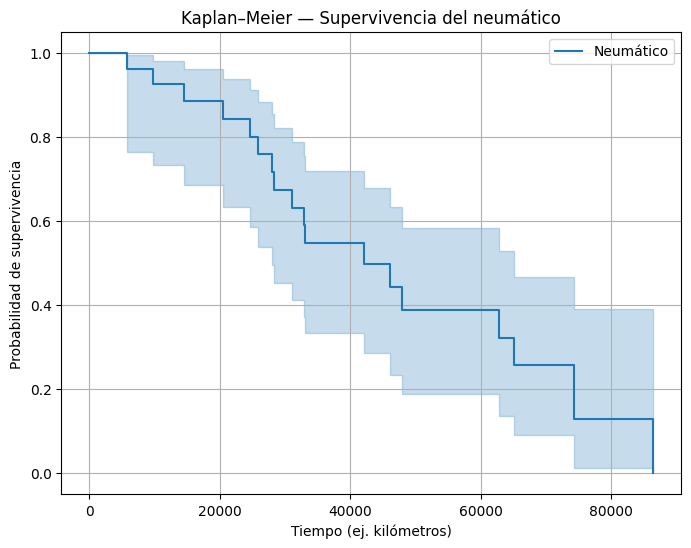

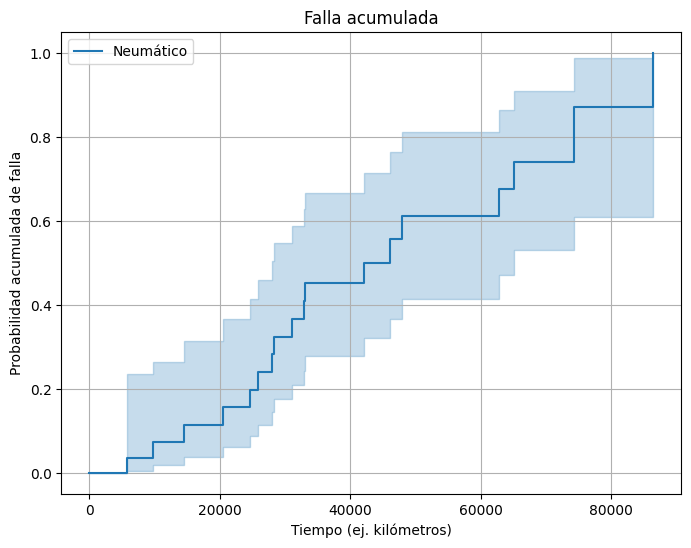

In [7]:

# Gráfico de la función de SUPERVIVENCIA S(t)
plt.figure(figsize=(8,6))                    # Define tamaño de la figura
kmf.plot_survival_function(ci_show=True)     # Dibuja S(t) con bandas de confianza
plt.title("Kaplan–Meier — Supervivencia del neumático")
plt.xlabel("Tiempo (ej. kilómetros)")
plt.ylabel("Probabilidad de supervivencia")
plt.grid(True)
plt.show()

# (Opcional) Gráfico de FALLA acumulada F(t) = 1 - S(t)
plt.figure(figsize=(8,6))
kmf.plot_cumulative_density()                # Aproximación a F(t) acumulada
plt.title("Falla acumulada")
plt.xlabel("Tiempo (ej. kilómetros)")
plt.ylabel("Probabilidad acumulada de falla")
plt.grid(True)
plt.show()



## 4) Tratamiento de la censura (documentación)

- Las observaciones con `c` (censuradas) **aportan información hasta su tiempo** y **no cuentan como fallas**.  
- En el cálculo de S(t) por Kaplan–Meier, la censura **reduce el número en riesgo** a partir del tiempo censurado, pero **no disminuye** la supervivencia directamente.  
- Si hay **mucha censura en la cola**, la **mediana de vida** podría no estar definida (S(t) no cruza 0.5); en ese caso se recomienda reportar **percentiles alternativos** o límites.



## 🧾 Conclusiones

1. **Vida útil típica:** la **mediana de vida** (si está definida) ofrece una métrica robusta para contratos de garantía y planeación de reemplazo.  
2. **Ritmo de desgaste:** descensos rápidos en S(t) pueden revelar **fallas tempranas** o lotes/condiciones adversas; una caída gradual sugiere desgaste progresivo.  
3. **Impacto de la censura:** una censura elevada indica que muchos neumáticos no fallaron durante el horizonte; interpretar como **estimación parcial**.  
4. **Incertidumbre:** bandas amplias de confianza pueden indicar **poca muestra** o heterogeneidad (mezcla de rutas, cargas o marcas).  
5. **Acción operativa:** el resultado orienta **intervalos de mantenimiento/reemplazo** y sirve como base para comparaciones entre **marcas o líneas** bajo condiciones similares.
